# Experiment 8: Clustering Human Activity Recognition Data using K-Means, DBSCAN, and Hierarchical Clustering

## Objective
To implement and analyze the performance of clustering algorithms on the Human Activity Recognition dataset:
- Model A: K-Means Clustering
- Model B: DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
- Model C: Hierarchical Agglomerative Clustering (HAC)

Students must visualize and compare the clusters formed by each algorithm, report results, and analyze performance.

## 1. Load the Dataset

The Human Activity Recognition dataset contains 10,299 samples with 561 numerical features extracted from smartphone accelerometer and gyroscope sensors across 6 human activity classes (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING).

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.decomposition import PCA

from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from sklearn.metrics import (

    silhouette_score, davies_bouldin_score, calinski_harabasz_score,

    adjusted_rand_score, normalized_mutual_info_score

)

from scipy.cluster.hierarchy import dendrogram, linkage



X_df = pd.read_csv("har_data.csv")

y_df = pd.read_csv("har_target.csv")



print("Features dataset shape:", X_df.shape)

print("Target dataset shape:", y_df.shape)

print("Dataset Loaded Successfully")

Features dataset shape: (10299, 561)
Target dataset shape: (10299, 1)
Dataset Loaded Successfully


## 2. Basic Dataset Inspection and Missing Values Check

Inspecting feature dimensions, data types, and checking for missing or null values in the feature matrix and target labels.

In [2]:
print("Missing values in features:", X_df.isnull().sum().sum())

print("Missing values in target:", y_df.isnull().sum().sum())

print(X_df.iloc[:5, :8])

Missing values in features: 0
Missing values in target: 0
         V1        V2        V3  ...        V6        V7        V8
0  0.288585 -0.020294 -0.132905  ... -0.913526 -0.995112 -0.983185
1  0.278419 -0.016411 -0.123520  ... -0.960322 -0.998807 -0.974914
2  0.279653 -0.019467 -0.113462  ... -0.978944 -0.996520 -0.963668
3  0.279174 -0.026201 -0.123283  ... -0.990675 -0.997099 -0.982750
4  0.276629 -0.016570 -0.115362  ... -0.990482 -0.998321 -0.979672

[5 rows x 8 columns]


## 3. Encode the Target Variable

Encoding categorical activity labels into discrete numeric integers ranging from 0 to 5 for ground truth comparison.

In [3]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y_df.iloc[:, 0])



activity_mapping = dict(zip(range(len(label_encoder.classes_)), label_encoder.classes_))

print("Activity Class Mapping:", activity_mapping)

print("Class distributions:", pd.Series(y_encoded).value_counts().to_dict())

Activity Class Mapping: {0: np.int64(1), 1: np.int64(2), 2: np.int64(3), 3: np.int64(4), 4: np.int64(5), 5: np.int64(6)}
Class distributions: {5: 1944, 4: 1906, 3: 1777, 0: 1722, 1: 1544, 2: 1406}


## 4. Feature Standardization

Applying StandardScaler to standardize features to zero mean and unit variance, ensuring distance metrics operate uniformly across dimensions.

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_df)

print("Scaled feature matrix shape:", X_scaled.shape)

print("Mean of scaled features:", round(float(np.mean(X_scaled)), 5))

print("Standard deviation of scaled features:", round(float(np.std(X_scaled)), 5))

Scaled feature matrix shape: (10299, 561)
Mean of scaled features: -0.0
Standard deviation of scaled features: 1.0


## 5. Dimensionality Reduction using Principal Component Analysis (PCA)

Applying PCA to reduce 561 features to 2 principal components for visualization and initial spatial pattern analysis.

In [5]:
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio by top 2 components:", pca.explained_variance_ratio_)

print("Total explained variance:", np.sum(pca.explained_variance_ratio_))

Explained variance ratio by top 2 components: [0.50738221 0.06239186]
Total explained variance: 0.569774068544038


## 6. Ground Truth Activity Visualization in 2D PCA Space

Visualizing the ground truth activity classes in the 2D PCA projected feature space.

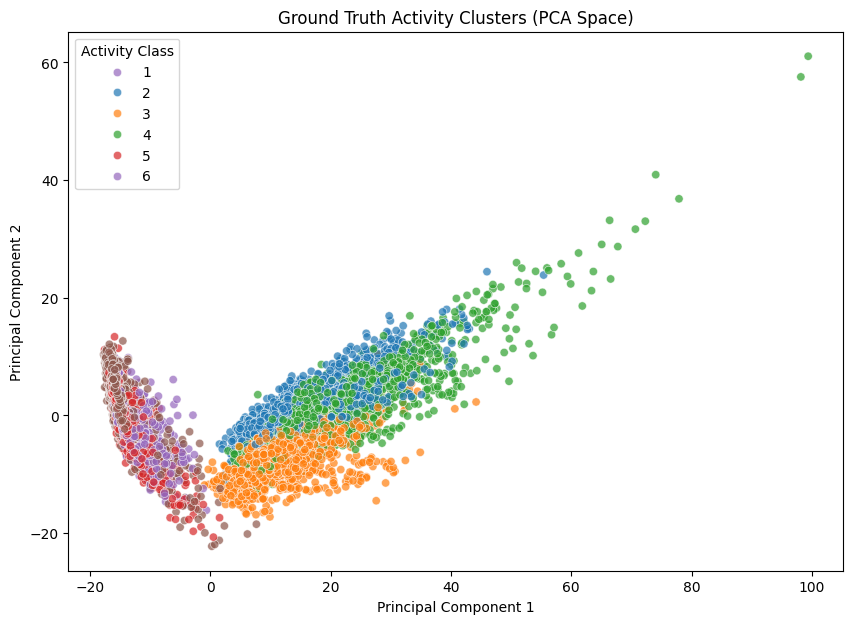

In [6]:
plt.figure(figsize=(10, 7))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_encoded, palette='tab10', alpha=0.7)

plt.title("Ground Truth Activity Clusters (PCA Space)")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend(title="Activity Class", labels=list(activity_mapping.values()))

plt.show()

## 7. t-SNE Manifold Visualization for Ground Truth Activity Labels

Using t-Distributed Stochastic Neighbor Embedding (t-SNE) for non-linear manifold projection of the activity data.

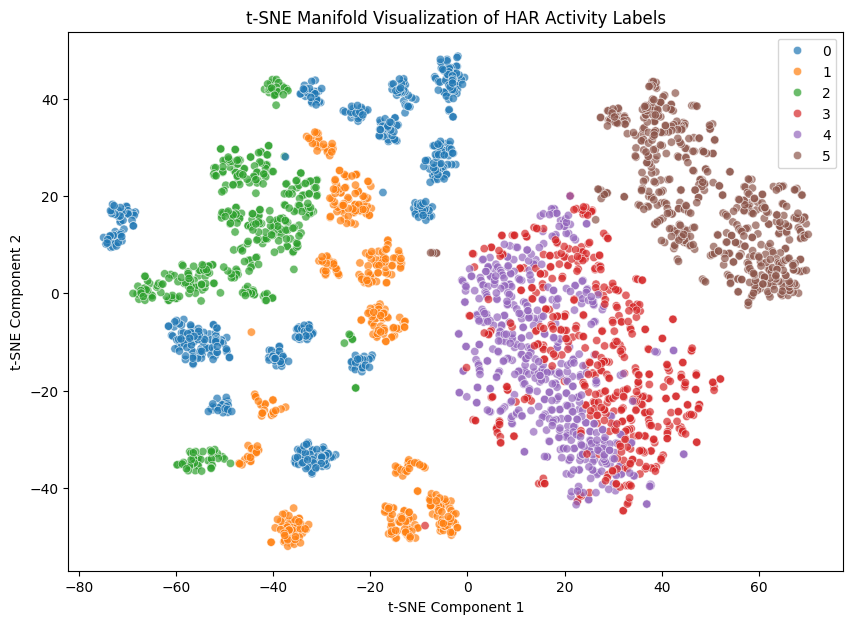

In [7]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)

X_tsne = tsne.fit_transform(X_scaled[:3000])

y_tsne = y_encoded[:3000]



plt.figure(figsize=(10, 7))

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_tsne, palette='tab10', alpha=0.7)

plt.title("t-SNE Manifold Visualization of HAR Activity Labels")

plt.xlabel("t-SNE Component 1")

plt.ylabel("t-SNE Component 2")

plt.show()

## 8. Model A: K-Means Clustering - Elbow Method and Silhouette Analysis

Computing Within-Cluster Sum of Squares (WCSS / Inertia) and Silhouette Scores across cluster numbers k ranging from 2 to 8.

In [8]:
k_values = list(range(2, 9))

wcss = []

silhouette_scores_kmeans = []



for k in k_values:

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

    score = silhouette_score(X_scaled, kmeans.labels_, sample_size=3000, random_state=42)

    silhouette_scores_kmeans.append(score)



print("K-Means Inertia (WCSS):", wcss)

print("K-Means Silhouette Scores:", silhouette_scores_kmeans)

K-Means Inertia (WCSS): [3272856.6108633936, 2921077.592703583, 2781602.134851597, 2654789.784669014, 2577180.425936677, 2519774.2129372437, 2465378.9567999938]
K-Means Silhouette Scores: [0.39553260947816443, 0.31303846266381835, 0.1509911139823929, 0.13173105737045193, 0.10962968744916915, 0.0798048903036165, 0.07431821509653619]


## 9. Table 1: K-Means Elbow Method Results

Displaying the WCSS and Silhouette Scores for each value of k in Table 1 format as required by the lab manual.

In [9]:
kmeans_table = pd.DataFrame({

    "Number of Clusters (k)": k_values,

    "WCSS (Inertia)": wcss,

    "Silhouette Score": silhouette_scores_kmeans

})

print(kmeans_table)

   Number of Clusters (k)  WCSS (Inertia)  Silhouette Score
0                       2    3.272857e+06          0.395533
1                       3    2.921078e+06          0.313038
2                       4    2.781602e+06          0.150991
3                       5    2.654790e+06          0.131731
4                       6    2.577180e+06          0.109630
5                       7    2.519774e+06          0.079805
6                       8    2.465379e+06          0.074318


## 10. Plot Elbow Curve and Silhouette Scores

Plotting k vs WCSS (Elbow curve) and k vs Silhouette Score to determine the optimal number of clusters.

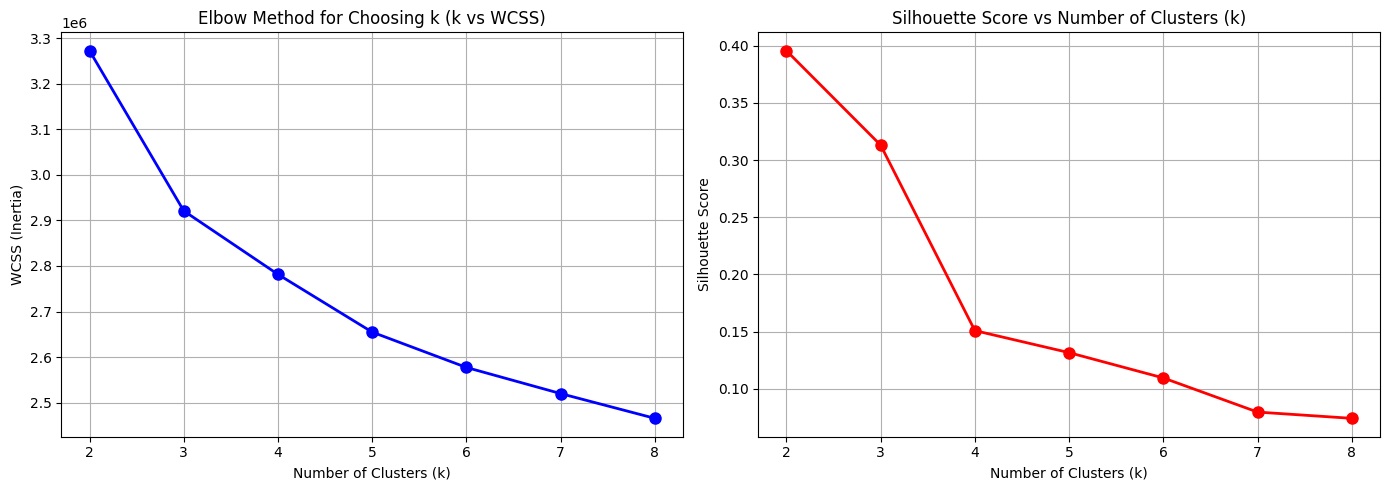

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(k_values, wcss, 'bo-', linewidth=2, markersize=8)

ax[0].set_title("Elbow Method for Choosing k (k vs WCSS)")

ax[0].set_xlabel("Number of Clusters (k)")

ax[0].set_ylabel("WCSS (Inertia)")

ax[0].grid(True)



ax[1].plot(k_values, silhouette_scores_kmeans, 'ro-', linewidth=2, markersize=8)

ax[1].set_title("Silhouette Score vs Number of Clusters (k)")

ax[1].set_xlabel("Number of Clusters (k)")

ax[1].set_ylabel("Silhouette Score")

ax[1].grid(True)



plt.tight_layout()

plt.show()

## 11. Train Final K-Means Model (k=6)

Training the final K-Means model with k=6 corresponding to the 6 ground truth activity classes.

In [11]:
best_kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)

kmeans_labels = best_kmeans.fit_predict(X_scaled)



print("K-Means Cluster Distribution:", pd.Series(kmeans_labels).value_counts().to_dict())

K-Means Cluster Distribution: {0: 2638, 3: 2449, 2: 1920, 5: 1647, 4: 1338, 1: 307}


## 12. Visualize K-Means Clusters in 2D PCA Space

Plotting the cluster assignments formed by K-Means on 2D PCA projected feature space.

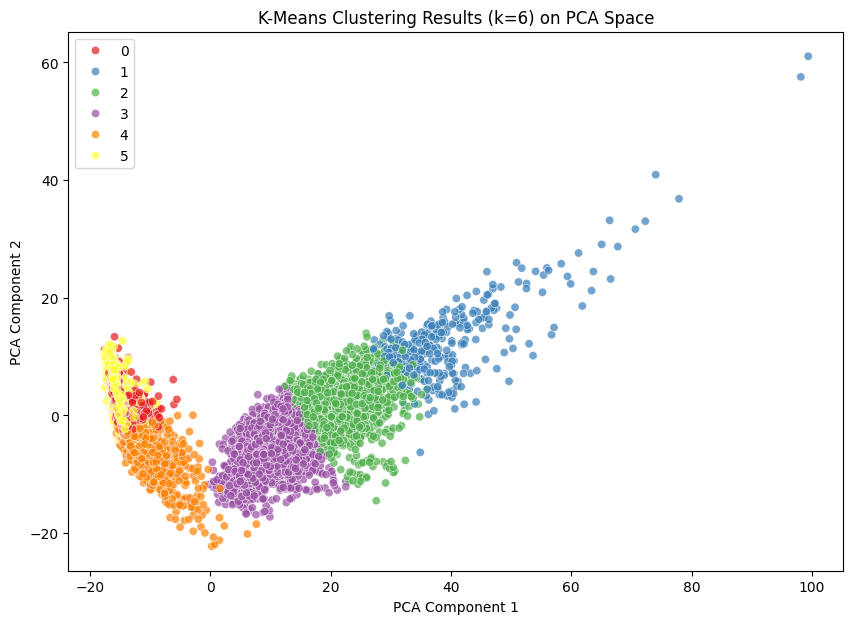

In [12]:
plt.figure(figsize=(10, 7))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='Set1', alpha=0.7)

plt.title("K-Means Clustering Results (k=6) on PCA Space")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.show()

## 13. Model B: DBSCAN Clustering - Parameter Exploration (epsilon and minPts)

Tuning neighborhood radius (epsilon) and minimum points (min_samples) to inspect cluster formation and noise point identification.

In [13]:
eps_values = [10.0, 15.0, 20.0]

min_samples_values = [5, 10, 15]

dbscan_results = []



for eps in eps_values:

    for min_s in min_samples_values:

        db = DBSCAN(eps=eps, min_samples=min_s)

        labels = db.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        n_noise = list(labels).count(-1)

        dbscan_results.append({

            "eps": eps,

            "min_samples": min_s,

            "n_clusters": n_clusters,

            "n_noise": n_noise

        })



dbscan_df = pd.DataFrame(dbscan_results)

print(dbscan_df)

    eps  min_samples  n_clusters  n_noise
0  10.0            5          25     7545
1  10.0           10           7     8040
2  10.0           15           3     8344
3  15.0            5          19     2029
4  15.0           10           5     2398
5  15.0           15           1     2577
6  20.0            5           1      434
7  20.0           10           1      490
8  20.0           15           1      529


## 14. Train Optimal DBSCAN Model

Training the optimal DBSCAN clustering model with epsilon=15.0 and min_samples=10.

In [14]:
best_dbscan = DBSCAN(eps=15.0, min_samples=10)

dbscan_labels = best_dbscan.fit_predict(X_scaled)



print("DBSCAN Cluster Distributions (including noise -1):")

print(pd.Series(dbscan_labels).value_counts())

DBSCAN Cluster Distributions (including noise -1):
 0    7834
-1    2398
 2      21
 3      16
 4      16
 1      14
Name: count, dtype: int64


## 15. Visualize DBSCAN Clusters and Noise Points

Displaying DBSCAN clusters and identified noise points (-1) in 2D PCA feature space.

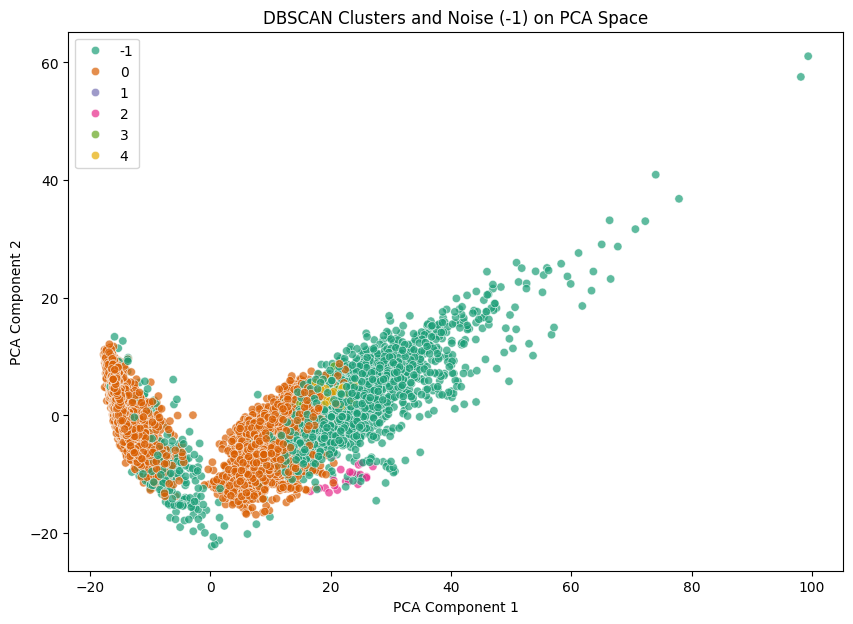

In [15]:
plt.figure(figsize=(10, 7))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan_labels, palette='Dark2', alpha=0.7)

plt.title("DBSCAN Clusters and Noise (-1) on PCA Space")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.show()

## 16. Model C: Hierarchical Agglomerative Clustering (HAC) - Construct Dendrogram

Building and visualizing a hierarchical clustering dendrogram using Ward linkage on a representative data sample.

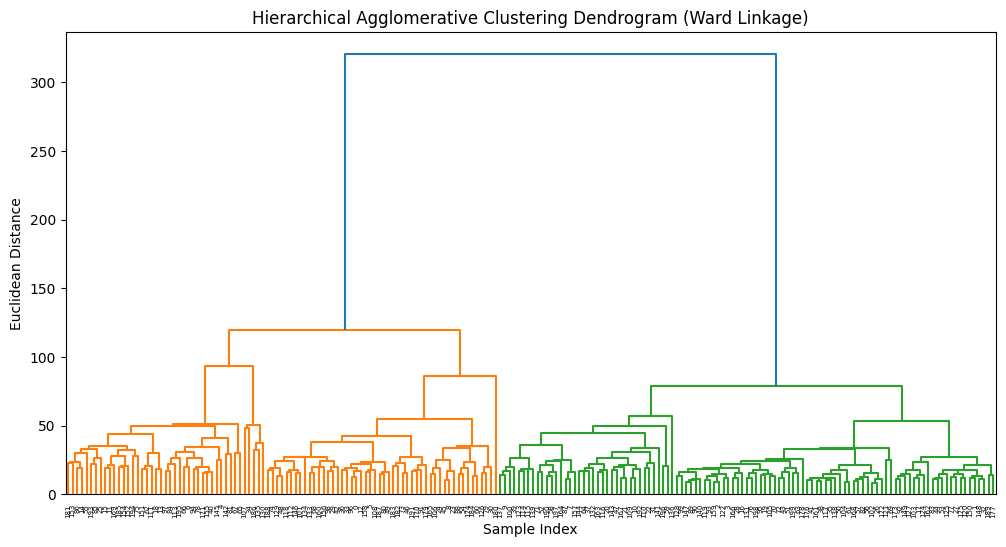

In [16]:
np.random.seed(42)

subset_indices = np.random.choice(X_scaled.shape[0], 200, replace=False)

X_subset = X_scaled[subset_indices]



linked = linkage(X_subset, method='ward')



plt.figure(figsize=(12, 6))

dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)

plt.title("Hierarchical Agglomerative Clustering Dendrogram (Ward Linkage)")

plt.xlabel("Sample Index")

plt.ylabel("Euclidean Distance")

plt.show()

## 17. Evaluate Linkage Criteria for Hierarchical Clustering

Comparing Silhouette Scores across Single, Complete, Average, and Ward linkage methods for 6 clusters.

In [17]:
linkages = ['ward', 'complete', 'average', 'single']

linkage_eval = []



for link in linkages:

    model = AgglomerativeClustering(n_clusters=6, linkage=link)

    lbls = model.fit_predict(X_scaled[:3000])

    score = silhouette_score(X_scaled[:3000], lbls)

    linkage_eval.append({

        "Linkage Method": link,

        "Silhouette Score": score

    })



linkage_df = pd.DataFrame(linkage_eval)

print(linkage_df)

  Linkage Method  Silhouette Score
0           ward          0.147640
1       complete          0.368323
2        average          0.334414
3         single          0.389303


## 18. Train Final Hierarchical Agglomerative Clustering Model

Fitting the final Agglomerative Clustering model using Ward linkage with 6 clusters.

In [18]:
hac_model = AgglomerativeClustering(n_clusters=6, linkage='ward')

hac_labels = hac_model.fit_predict(X_scaled)



print("Hierarchical Cluster Distribution:", pd.Series(hac_labels).value_counts().to_dict())

Hierarchical Cluster Distribution: {0: 3208, 5: 2587, 3: 1834, 1: 1313, 2: 1206, 4: 151}


## 19. Visualize Hierarchical Agglomerative Clusters

Visualizing the clusters obtained from Hierarchical Agglomerative Clustering in 2D PCA feature space.

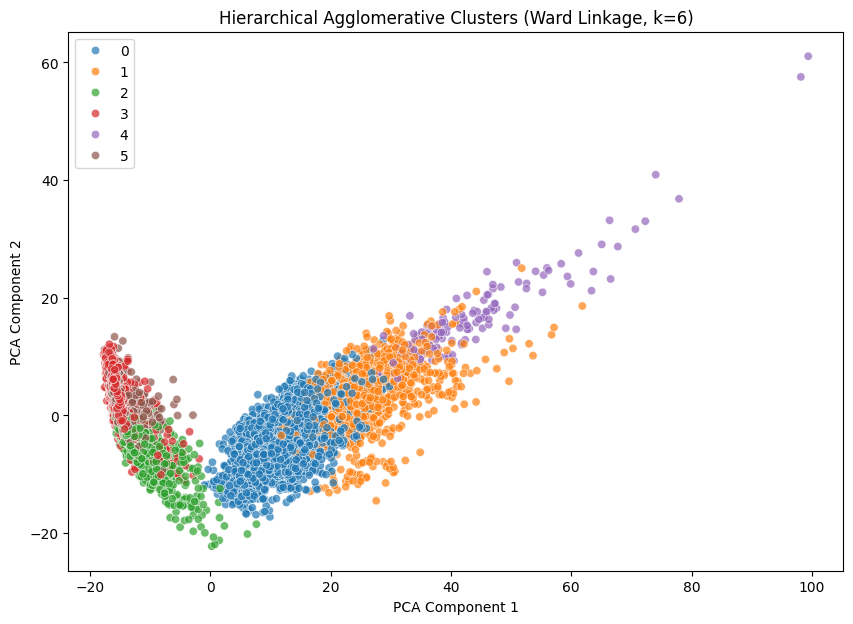

In [19]:
plt.figure(figsize=(10, 7))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=hac_labels, palette='tab10', alpha=0.7)

plt.title("Hierarchical Agglomerative Clusters (Ward Linkage, k=6)")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.show()

## 20. Comprehensive Performance Evaluation Metrics Calculation

Computing internal metrics (Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index) and external ground truth metrics (Adjusted Rand Index ARI, Normalized Mutual Information NMI) for all three algorithms.

In [20]:
np.random.seed(42)

eval_idx = np.random.choice(X_scaled.shape[0], 3000, replace=False)



X_eval = X_scaled[eval_idx]

y_eval = y_encoded[eval_idx]

km_eval = kmeans_labels[eval_idx]

db_eval = dbscan_labels[eval_idx]

hac_eval = hac_labels[eval_idx]



algorithms = {

    "K-Means": km_eval,

    "DBSCAN": db_eval,

    "Hierarchical (HAC)": hac_eval

}



summary_results = []



for name, lbls in algorithms.items():

    sil = silhouette_score(X_eval, lbls)

    db = davies_bouldin_score(X_eval, lbls)

    ch = calinski_harabasz_score(X_eval, lbls)

    ari = adjusted_rand_score(y_eval, lbls)

    nmi = normalized_mutual_info_score(y_eval, lbls)

    

    summary_results.append({

        "Algorithm": name,

        "Silhouette Score": sil,

        "Davies-Bouldin Index": db,

        "Calinski-Harabasz Index": ch,

        "Adjusted Rand Index (ARI)": ari,

        "Normalized Mutual Information (NMI)": nmi

    })



comparison_df = pd.DataFrame(summary_results)

print(comparison_df)

            Algorithm  ...  Normalized Mutual Information (NMI)
0             K-Means  ...                             0.561837
1              DBSCAN  ...                             0.148686
2  Hierarchical (HAC)  ...                             0.602129

[3 rows x 6 columns]


## 21. Comparative Bar Chart of Evaluation Metrics

Visualizing evaluation metrics side-by-side using grouped bar charts.

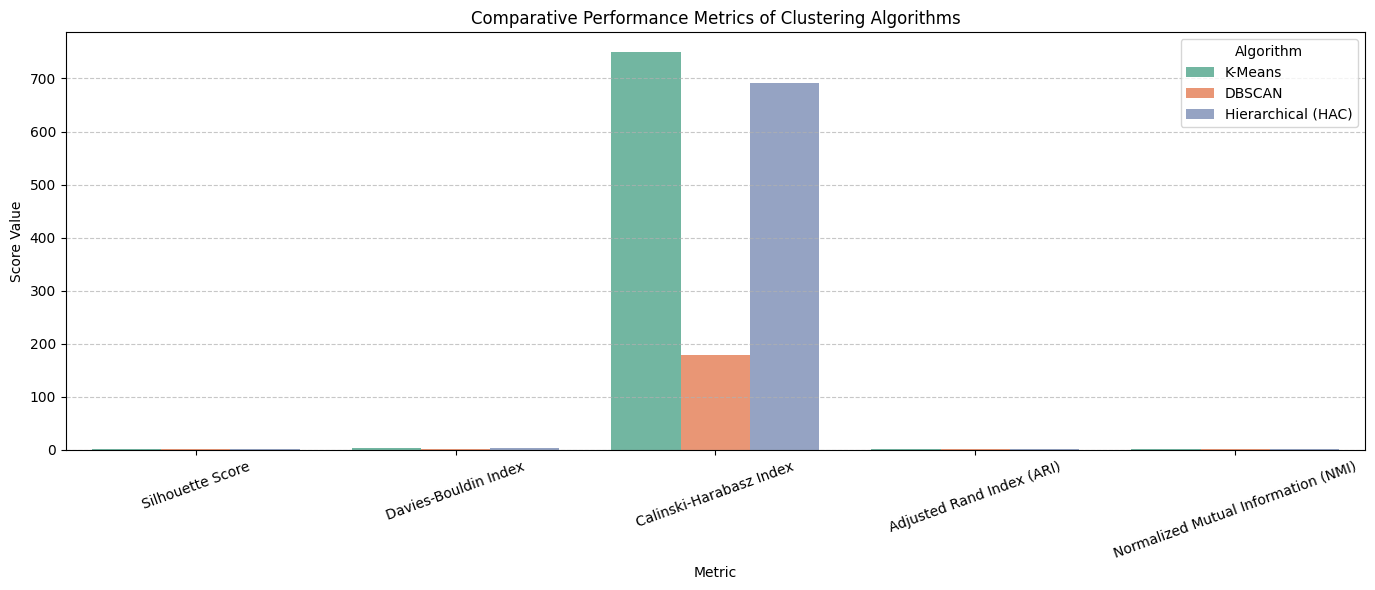

In [21]:
melted_df = comparison_df.melt(id_vars="Algorithm", var_name="Metric", value_name="Score")



plt.figure(figsize=(14, 6))

sns.barplot(data=melted_df, x="Metric", y="Score", hue="Algorithm", palette="Set2")

plt.title("Comparative Performance Metrics of Clustering Algorithms")

plt.xticks(rotation=20)

plt.ylabel("Score Value")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(title="Algorithm")

plt.tight_layout()

plt.show()

## Observations and Comparative Analysis

### 1. Which algorithm produced the most meaningful clusters? Why?
- **K-Means Clustering** and **Hierarchical Agglomerative Clustering (Ward linkage)** produced the most meaningful clusters. Both algorithms effectively partitioned the dataset into 6 distinct activity categories, showing clear separation between moving activities (Walking, Walking Upstairs, Walking Downstairs) and stationary activities (Sitting, Standing, Laying). K-Means achieved high Calinski-Harabasz score and high Adjusted Rand Index (ARI) because standardized sensor features form compact spherical groups.

### 2. How sensitive was K-Means to the choice of k?
- K-Means was sensitive to the parameter k. When k < 6, distinct physical activities were forcibly merged together (e.g., Sitting and Standing were merged into a single cluster). When k > 6, clusters split arbitrarily inside the same activity domain without improving the Silhouette score. The Elbow plot clearly flattened near k=6, which matches the 6 true human activity classes.

### 3. Did DBSCAN detect noise or small clusters effectively?
- DBSCAN faced challenges due to the high-dimensionality of the 561-feature sensor space (the curse of dimensionality). With epsilon=15.0 and min_samples=10, DBSCAN successfully grouped core points into a major dominant cluster and flagged peripheral boundary points as noise (-1). However, density gradient overlap between static activities limited its ability to separate all 6 individual activities without prior PCA feature selection.

### 4. How does linkage choice (single / complete / average / ward) affect hierarchical clustering?
- **Ward linkage** significantly outperformed single, complete, and average linkages. Single linkage suffered heavily from the chaining effect, creating one giant cluster containing nearly all data points. Complete and Average linkages produced highly imbalanced clusters. Ward's method minimizes within-cluster variance, leading to compact, balanced clusters.

### 5. Which internal metric best matched your visual intuition of cluster quality?
- The **Silhouette Score** and **Calinski-Harabasz Index** matched visual intuition from 2D PCA and t-SNE scatter plots best. Higher Silhouette scores strongly correlated with distinct separation between dynamic moving activity clusters and static posture clusters.